In [ ]:
from utils.ocean_basins import get_zoned_df
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from utils.plot_style import set_style_width_10

In [ ]:
features = ['SST', 'SAL', 'ice_frac', 'mixed_layer_depth', 'heat_flux_down', 'water_flux_up', 'stress_X', 'stress_Y', 'currents_X', 'co2flux_pre']

# path = "../../../data/"
path =  "../../../../../../../../Volumes/T7Shield/exp_1/ORCA025.L46.LIM2vp.CFCSF6.MOPS.JRA.LP04-KLP002.hind_"

data_1958 = pd.read_pickle(path + '1958_df.pkl')
data_2018 = pd.read_pickle(path + '2018_df.pkl')
data_1958["month"] = data_1958["time_counter"].apply(lambda x: x.month)
data_2018["month"] = data_2018["time_counter"].apply(lambda x: x.month)

months = [1,7]
month_labels = ['','January','','','April','','','July','','','October','','']
region_labels = ['Arctic','Equatorial Pacific','North Atlantic','Southern Ocean']

datasets = {
    "1958": data_1958,
    "2018": data_2018
}

In [15]:
for year_label, df in datasets.items():
    set_style_width_10()
    
    regions = get_zoned_df(df)
    
    fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 11))
    axes = axes.flatten()
    
    plot_idx = 0
    
    for region_idx, region_df in enumerate(regions):
        if region_idx >= 2:
            break
        for month in months:
            month_df = region_df[region_df['month'] == month]
            month_df_ocean = month_df[month_df['tmask'] == 1]
            corr_df = month_df_ocean[features].corr(method='pearson').fillna(0)
            
            ax = axes[plot_idx]
            cax = ax.imshow(corr_df, cmap='coolwarm', vmin=-1, vmax=1)
            
            ax.set_xticks(np.arange(len(features)))
            ax.set_xticklabels(features, rotation=45, ha='right')
            
            if plot_idx % 2 == 0:  # first column
                ax.set_yticks(np.arange(len(features)))
                ax.set_yticklabels(features)
            else:  # hide y-ticks for second column
                ax.set_yticks([])
        
            for i in range(len(features)):
                for j in range(len(features)):
                    ax.text(j, i, f"{corr_df.iloc[i, j]:.2f}", ha='center', va='center', color='black')
            
            ax.set_title(f"{region_labels[region_idx]} {month_labels[month]} {year_label}")
            plot_idx += 1
    
    fig.tight_layout(rect=[0, 0, 0.92, 1])


    cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
    fig.colorbar(cax, cax=cbar_ax)
    plt.savefig("../../outputs/plots/heatmaps/heatmap_1_" + year_label + ".png", dpi=300, bbox_inches='tight')
    plt.close()


    fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 11))
    axes = axes.flatten()
    
    plot_idx = 0
    
    for region_idx, region_df in enumerate(regions):
        if region_idx < 2:
            continue
        for month in months:
            month_df = region_df[region_df['month'] == month]
            month_df_ocean = month_df[month_df['tmask'] == 1]
            corr_df = month_df_ocean[features].corr(method='pearson').fillna(0)
            
            ax = axes[plot_idx]
            cax = ax.imshow(corr_df, cmap='coolwarm', vmin=-1, vmax=1)
            
            ax.set_xticks(np.arange(len(features)))
            ax.set_xticklabels(features, rotation=45, ha='right')
            
            if plot_idx % 2 == 0: 
                ax.set_yticks(np.arange(len(features)))
                ax.set_yticklabels(features)
            else: 
                ax.set_yticks([])
            
            for i in range(len(features)):
                for j in range(len(features)):
                    ax.text(j, i, f"{corr_df.iloc[i, j]:.2f}", ha='center', va='center', color='black')
            
            ax.set_title(f"{region_labels[region_idx]} {month_labels[month]} {year_label}")
            plot_idx += 1
    
    fig.tight_layout(rect=[0, 0, 0.92, 1])


    cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
    fig.colorbar(cax, cax=cbar_ax)
    plt.savefig("../../outputs/plots/heatmaps/heatmap_2_" + year_label + ".png", dpi=300, bbox_inches='tight')
    plt.close()


/Users/jakobmeggendorfer/Documents/CAU/Masterarbeit/master-thesis/src/utils/ocean_basins.py:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  zone_ARCTIC['zone'] = 'ARCTIC'
/Users/jakobmeggendorfer/Documents/CAU/Masterarbeit/master-thesis/src/utils/ocean_basins.py:56: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  zone_SOUTHERN_OCEAN['zone'] = 'SOUTHERN_OCEAN'
/Users/jakobmeggendorfer/Documents/CAU/Masterarbeit/master-thesis/src/utils/ocean_basins.py:43: SettingWithCopyWarning: 
A value is trying to be set o

In [ ]:
for year_label, df in datasets.items():
    set_style_width_10()
    
    regions = get_zoned_df(df)
    
    for region_idx, region_df in enumerate(regions):
        fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))
        axes = axes.flatten()
        plot_idx = 0

        for month in months:
            month_df = region_df[region_df['month'] == month]
            month_df_ocean = month_df[month_df['tmask'] == 1]
            corr_df = month_df_ocean[features].corr(method='pearson').fillna(0)
            
            ax = axes[plot_idx]
            cax = ax.imshow(corr_df, cmap='coolwarm', vmin=-1, vmax=1)
            
            ax.set_xticks(np.arange(len(features)))
            ax.set_xticklabels(features, rotation=45, ha='right')
            
            if plot_idx % 2 == 0:  # first column
                ax.set_yticks(np.arange(len(features)))
                ax.set_yticklabels(features)
            else:  # hide y-ticks for second column
                ax.set_yticks([])
        
            for i in range(len(features)):
                for j in range(len(features)):
                    ax.text(j, i, f"{corr_df.iloc[i, j]:.2f}", ha='center', va='center', color='black')
            
            ax.set_title(f"{region_labels[region_idx]} {month_labels[month]} {year_label}")
            plot_idx += 1
    
        fig.tight_layout(rect=[0, 0, 0.92, 1])


        cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
        fig.colorbar(cax, cax=cbar_ax)
        plt.savefig("../../outputs/plots/heatmaps/heatmap_" + str(region_idx) + "_" + year_label + ".png", dpi=300, bbox_inches='tight')
        plt.close()


    # fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 11))
    # axes = axes.flatten()
    
    # plot_idx = 0
    
    # for region_idx, region_df in enumerate(regions):
    #     if region_idx < 2:
    #         continue
    #     for month in months:
    #         month_df = region_df[region_df['month'] == month]
    #         month_df_ocean = month_df[month_df['tmask'] == 1]
    #         corr_df = month_df_ocean[features].corr(method='pearson').fillna(0)
            
    #         ax = axes[plot_idx]
    #         cax = ax.imshow(corr_df, cmap='coolwarm', vmin=-1, vmax=1)
            
    #         ax.set_xticks(np.arange(len(features)))
    #         ax.set_xticklabels(features, rotation=45, ha='right')
            
    #         if plot_idx % 2 == 0: 
    #             ax.set_yticks(np.arange(len(features)))
    #             ax.set_yticklabels(features)
    #         else: 
    #             ax.set_yticks([])
            
    #         for i in range(len(features)):
    #             for j in range(len(features)):
    #                 ax.text(j, i, f"{corr_df.iloc[i, j]:.2f}", ha='center', va='center', color='black')
            
    #         ax.set_title(f"{region_labels[region_idx]} {month_labels[month]} {year_label}")
    #         plot_idx += 1
    
    # fig.tight_layout(rect=[0, 0, 0.92, 1])


    # cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
    # fig.colorbar(cax, cax=cbar_ax)
    # plt.savefig("../../outputs/plots/heatmaps/heatmap_2_" + year_label + ".png", dpi=300, bbox_inches='tight')
    # plt.close()


In [ ]:
for year_label, df in datasets.items():
    set_style_width_10()

    regions = get_zoned_df(df)  # returns a list of 4 DataFrames

    for region_idx, region_df in enumerate(regions):
        for month in months:
            month_df = region_df[region_df['month'] == month]
            month_df_ocean = month_df[month_df['tmask'] == 1]

            # Scatter plot of ice fraction vs CO₂ flux
            plt.figure(figsize=(8,6))
            plt.scatter(
                month_df_ocean["ice_frac"],
                month_df_ocean["co2flux"],
                alpha=0.3, s=10, edgecolor="none"
            )

            plt.xlabel("Ice Fraction")
            plt.ylabel("CO₂ Flux")
            plt.title("Scatter Plot: Ice Fraction vs CO₂ Flux")
            plt.grid(True, linestyle='--', alpha=0.4)
            plt.tight_layout()
            plt.show()

/Users/jakobmeggendorfer/Documents/CAU/Masterarbeit/master-thesis/src/utils/ocean_basins.py:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  zone_ARCTIC['zone'] = 'ARCTIC'
/Users/jakobmeggendorfer/Documents/CAU/Masterarbeit/master-thesis/src/utils/ocean_basins.py:56: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  zone_SOUTHERN_OCEAN['zone'] = 'SOUTHERN_OCEAN'


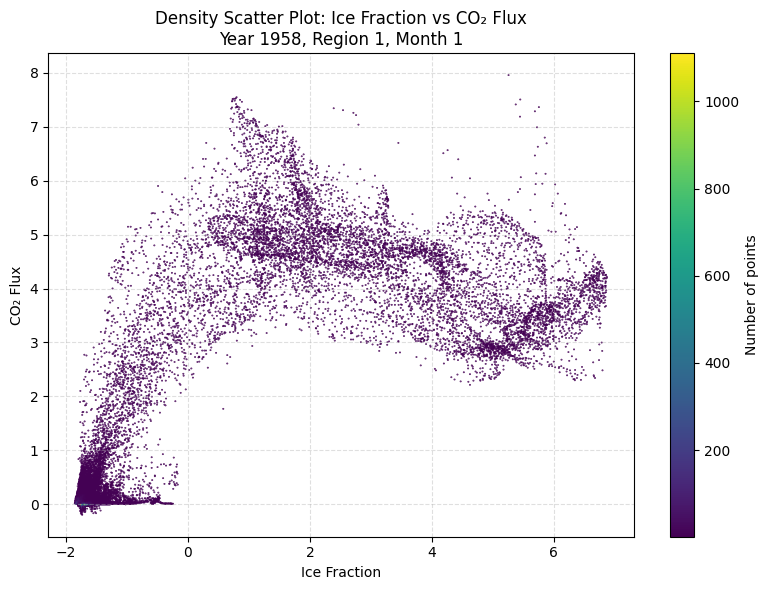

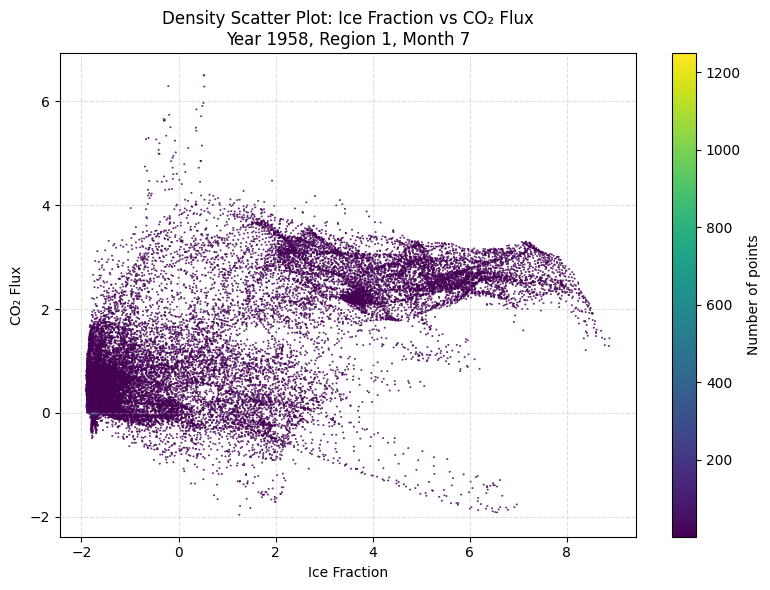

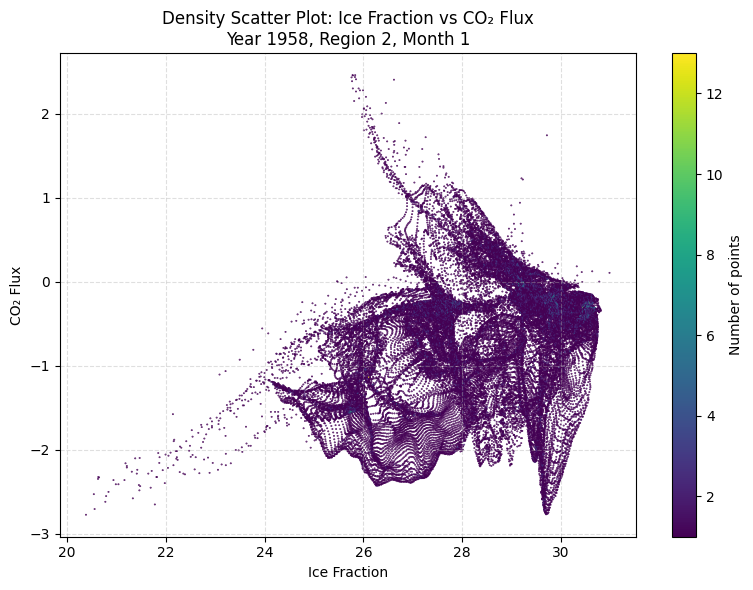

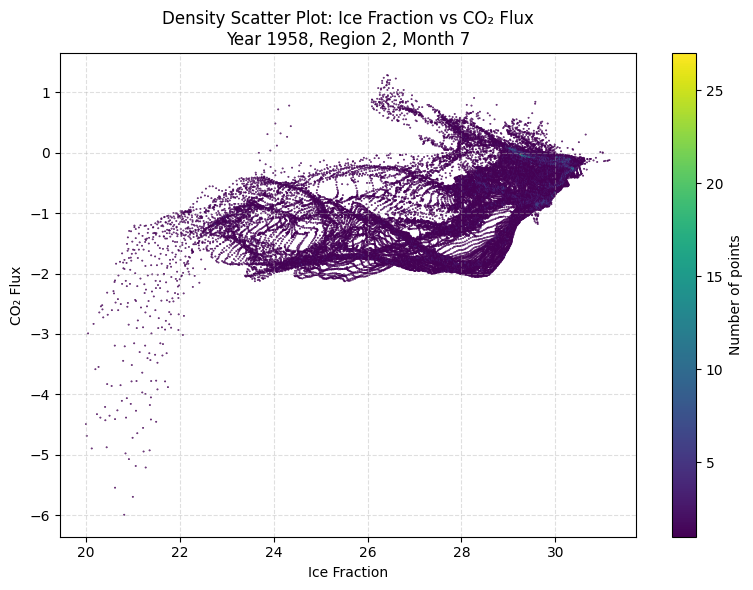

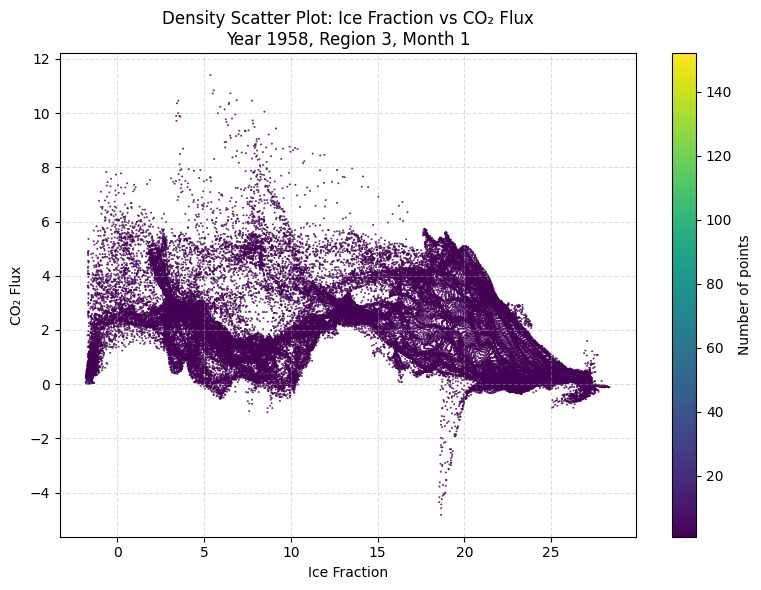

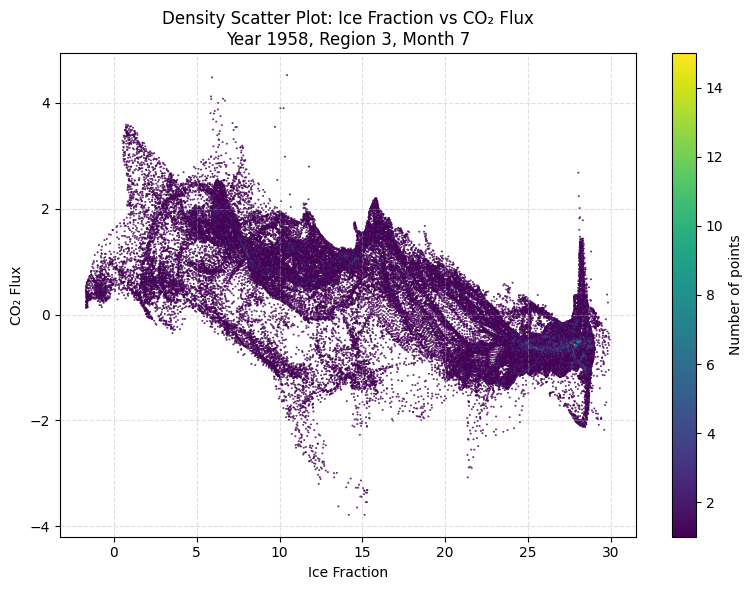

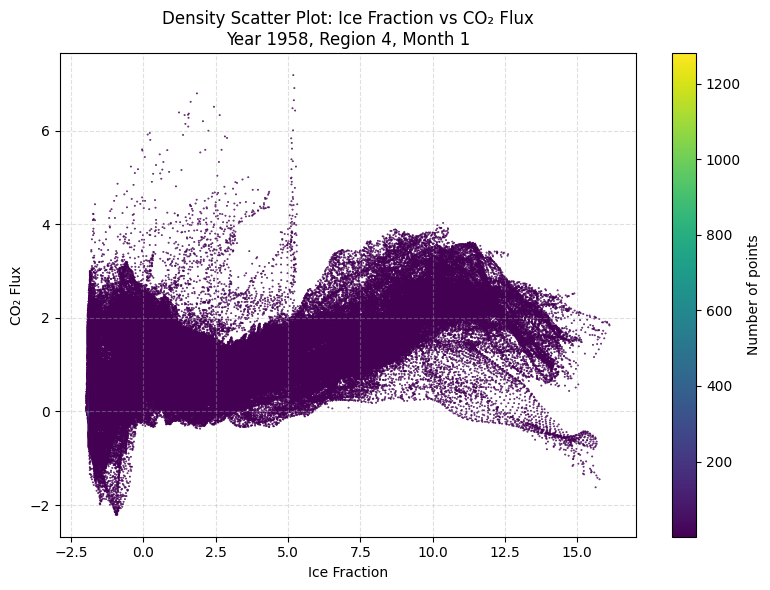

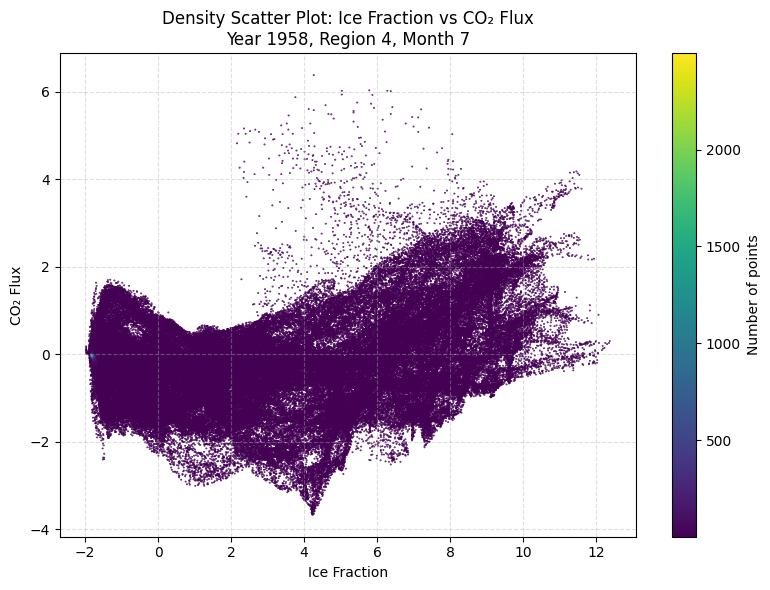

/Users/jakobmeggendorfer/Documents/CAU/Masterarbeit/master-thesis/src/utils/ocean_basins.py:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  zone_ARCTIC['zone'] = 'ARCTIC'
/Users/jakobmeggendorfer/Documents/CAU/Masterarbeit/master-thesis/src/utils/ocean_basins.py:56: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  zone_SOUTHERN_OCEAN['zone'] = 'SOUTHERN_OCEAN'


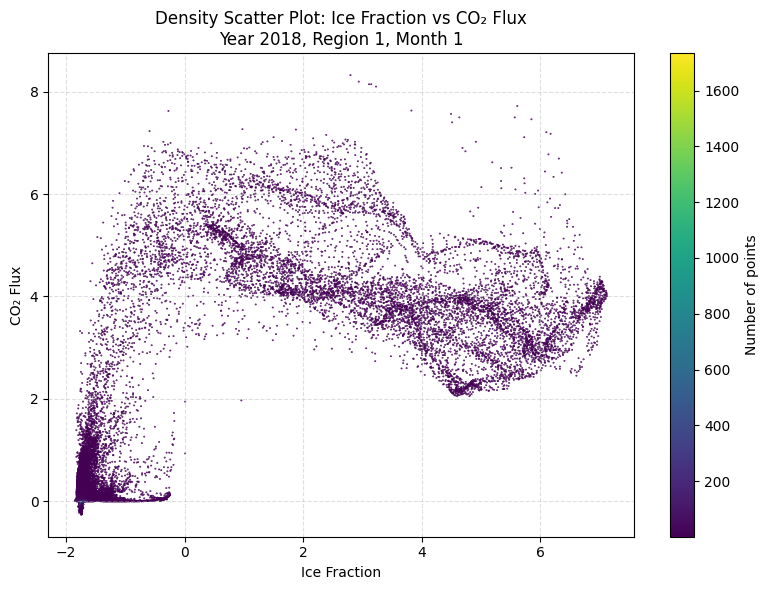

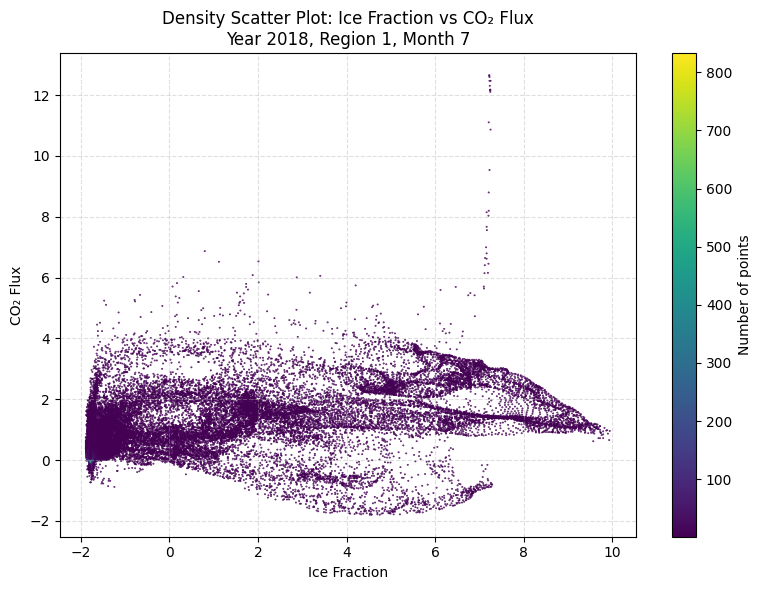

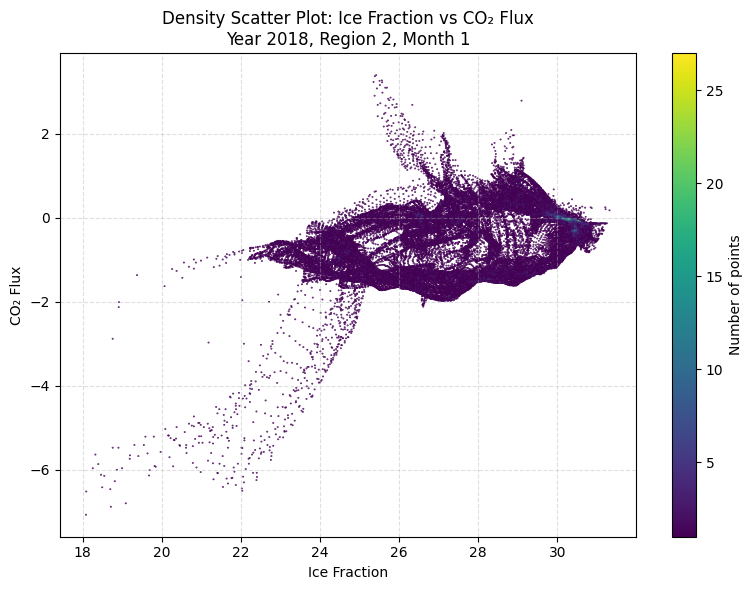

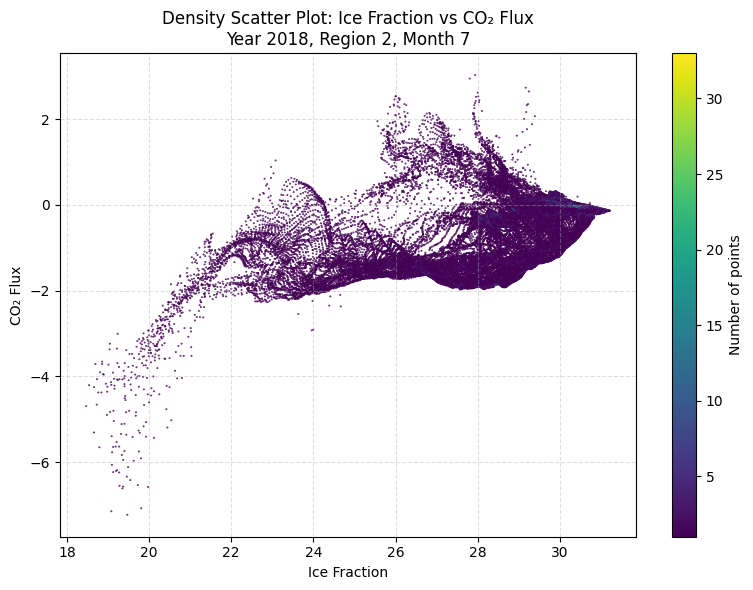

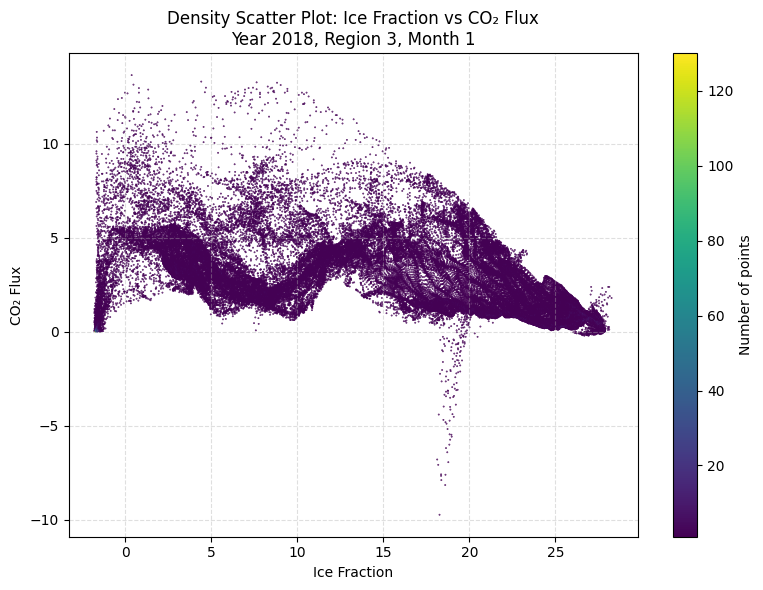

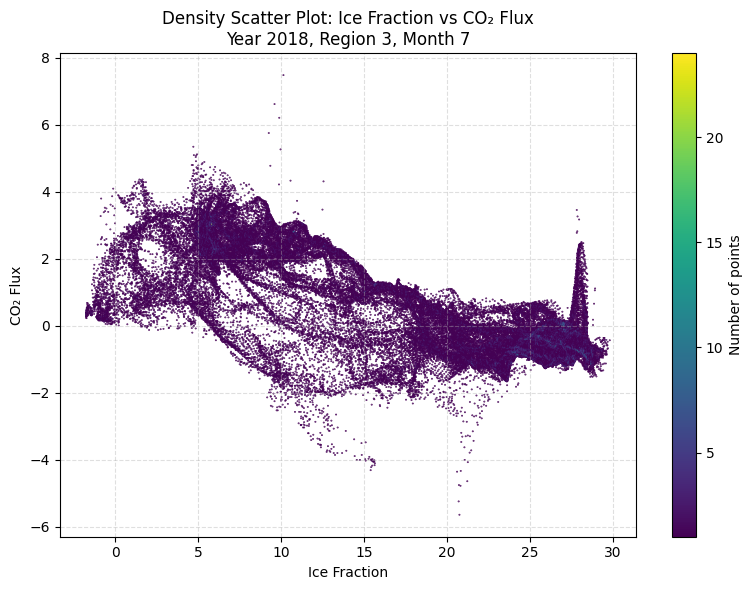

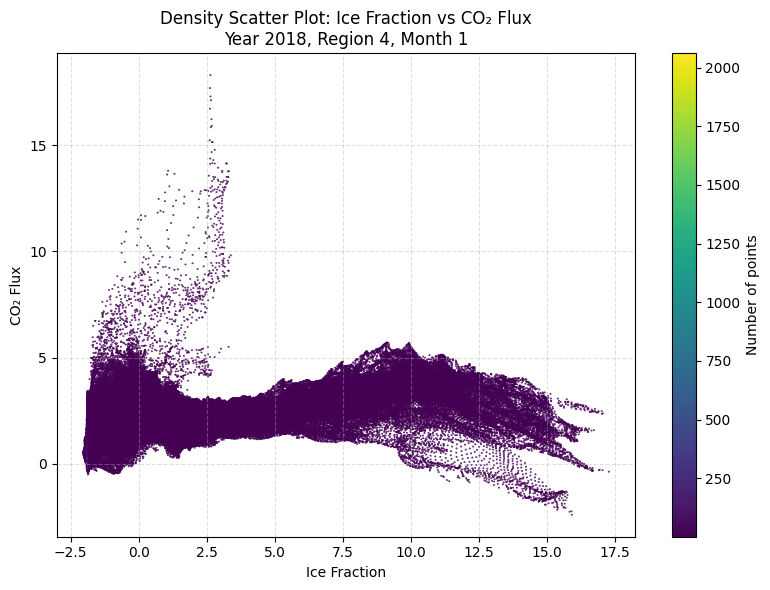

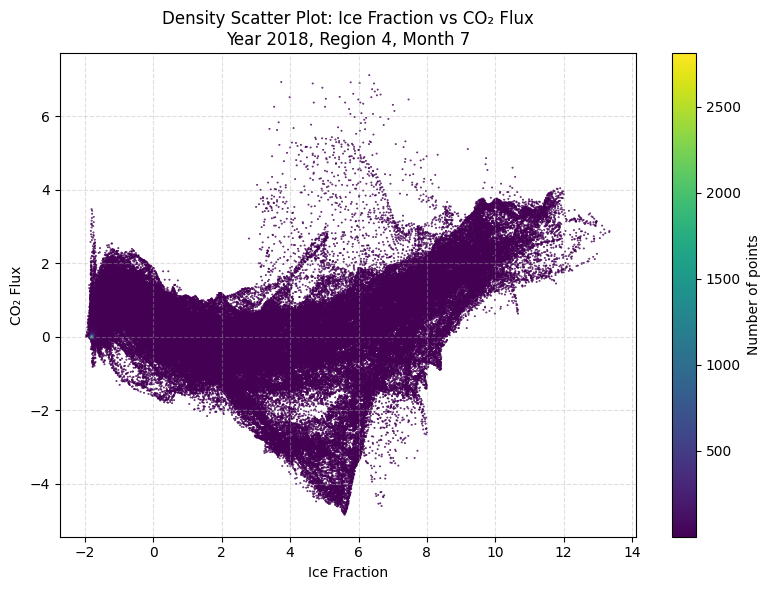

In [7]:
for year_label, df in datasets.items():
    set_style_width_10()

    regions = get_zoned_df(df)  # returns a list of 4 DataFrames

    for region_idx, region_df in enumerate(regions):
        for month in months:
            month_df = region_df[region_df['month'] == month]
            month_df_ocean = month_df[month_df['tmask'] == 1]

            # Density scatter plot of ice fraction vs CO₂ flux
            plt.figure(figsize=(8,6))
            hb = plt.hexbin(
                month_df_ocean["SST"],
                month_df_ocean["co2flux"],
                gridsize=1000,  # number of hexagons along x-axis
                cmap='viridis',  # color map
                mincnt=1,       # minimum number of points in a hex to be colored
            )
            plt.colorbar(hb, label='Number of points')

            plt.xlabel("Ice Fraction")
            plt.ylabel("CO₂ Flux")
            plt.title(f"Density Scatter Plot: Ice Fraction vs CO₂ Flux\nYear {year_label}, Region {region_idx+1}, Month {month}")
            plt.grid(True, linestyle='--', alpha=0.4)
            plt.tight_layout()
            plt.show()
            plt.close()